# Full-Pipeline Fidelity Analysis (Solidity, with_kernel_spec)

Standalone fidelity report on the ~800 full-pipeline samples in
`nl2solidity/dataset/with_kernel_spec/` \u2014 **no naive baseline exists yet**, so this
is not a naive-vs-pipeline comparison. It characterizes how well the full
MoE + refinement + kernel + spec-alignment + security pipeline satisfies its own
quality gates: compiler validity, Foundry execution, Slither security, and
NL/spec-alignment similarity, overall and broken out by domain (category).

Everything here reads cached `meta.json` (no LLM/solc/forge/slither calls), so
the whole notebook runs in well under a second.


In [1]:
import json
import statistics
import sys
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "nl2solidity"))

WKS_DIR = ROOT / "nl2solidity" / "dataset" / "with_kernel_spec"

from analyze_with_kernel_spec import load_records, overview, gate_funnel, by_category

records = load_records(WKS_DIR)
n = len(records)
assert n > 0, f"No samples found under {WKS_DIR}"
print(f"Loaded {n} samples from {WKS_DIR.relative_to(ROOT)}")

ov = overview(records)
funnel = gate_funnel(records)
cats = by_category(records)

sims = [r.similarity for r in records if r.similarity is not None]
COLOR = "#4c72b0"
COLOR_BAD = "#c44e52"
COLOR_MED = "#dd8452"

print(json.dumps(ov, indent=2))


Loaded 800 samples from nl2solidity/dataset/with_kernel_spec
{
  "n": 800,
  "quality_A_rate": 45.625,
  "quality_counts": {
    "A": 365,
    "B": 435
  },
  "valid_rate": 94.875,
  "mean_errors": 0.11125,
  "fuzz_pass_rate": 74.125,
  "fuzz_status_counts": {
    "passed": 593,
    "failed": 104,
    "skipped": 19,
    "build_failed": 84
  },
  "properties_status_counts": {
    "skipped": 228,
    "passed": 242,
    "failed": 210,
    "build_failed": 120
  },
  "execution_clean_rate": 85.875,
  "mean_contract_defects": 0.20625,
  "security_clean_rate": 82.125,
  "mean_findings": 3.905,
  "mean_actionable": 0.53,
  "alignment_accepted_rate": 55.625,
  "mean_similarity": 0.9462255,
  "median_similarity": 0.9474,
  "all_four_gates_clean_rate": 45.625
}


---
## 1. Quality-Gate Funnel

`quality: "A"` requires ALL four gates to pass: the contract compiles, spec
alignment is accepted, Foundry execution has zero contract-level defects, and
Slither has zero actionable (High/Medium) findings. This funnel shows where
samples are lost.


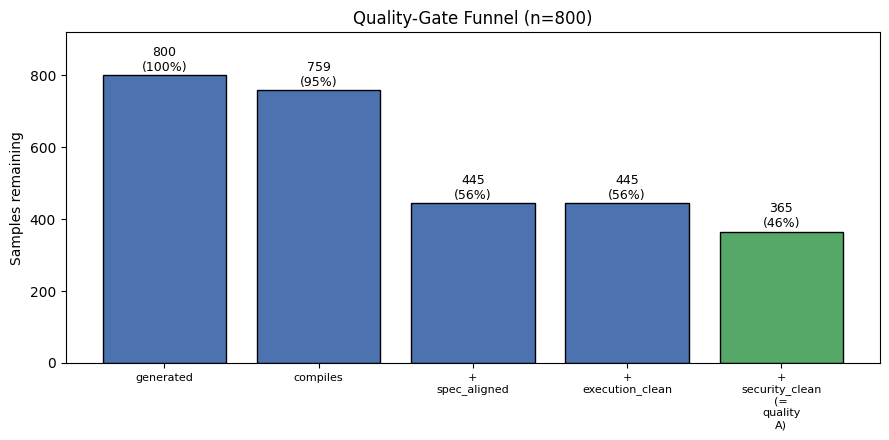

Gate                                 n  cumulative %   step drop
----------------------------------------------------------------
generated                          800        100.0%           0
compiles                           759         94.9%          41
+ spec_aligned                     445         55.6%         314
+ execution_clean                  445         55.6%           0
+ security_clean (= quality A)     365         45.6%          80


In [2]:
labels = list(funnel.keys())
values = list(funnel.values())

fig, ax = plt.subplots(figsize=(9, 4.5))
bar_colors = [COLOR] * len(values)
bar_colors[-1] = "#55a868"
bars = ax.bar(range(len(values)), values, color=bar_colors, edgecolor="black")
for i, v in enumerate(values):
    pct = v / n * 100
    ax.text(i, v + n * 0.015, f"{v}\n({pct:.0f}%)", ha="center", fontsize=9)
ax.set_xticks(range(len(values)), [l.replace(" ", "\n") for l in labels], fontsize=8)
ax.set_ylabel("Samples remaining")
ax.set_title(f"Quality-Gate Funnel (n={n})")
ax.set_ylim(0, n * 1.15)
plt.tight_layout()
plt.show()

print(f"{'Gate':<32}{'n':>6}{'cumulative %':>14}{'step drop':>12}")
print("-" * 64)
prev = n
for k, v in funnel.items():
    print(f"{k:<32}{v:>6}{v/n*100:>13.1f}%{prev-v:>12}")
    prev = v


---
## 2. Compiler Validity

solc compile results, as recorded by the pipeline at generation time.


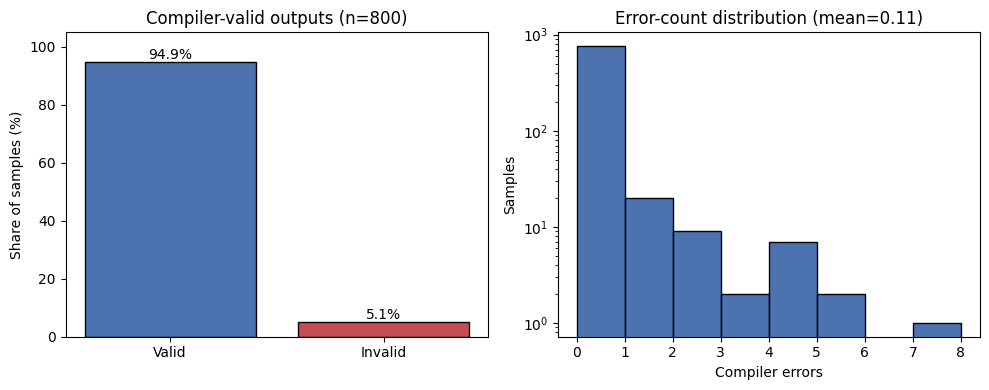

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(["Valid", "Invalid"], [ov["valid_rate"], 100 - ov["valid_rate"]],
            color=[COLOR, COLOR_BAD], edgecolor="black")
for i, v in enumerate([ov["valid_rate"], 100 - ov["valid_rate"]]):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha="center")
axes[0].set_ylabel("Share of samples (%)")
axes[0].set_title(f"Compiler-valid outputs (n={n})")
axes[0].set_ylim(0, 105)

errs = [r.error_count for r in records]
axes[1].hist([e for e in errs if e >= 0], bins=range(0, max(errs, default=1) + 2),
             color=COLOR, edgecolor="black")
axes[1].set_xlabel("Compiler errors")
axes[1].set_ylabel("Samples")
axes[1].set_title(f"Error-count distribution (mean={ov['mean_errors']:.2f})")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()


---
## 3. Foundry Execution

Fuzz-tier and property-tier verdicts (`passed` / `failed` / `build_failed` /
`skipped`), plus contract-level execution defects (real bugs the harness
found) versus harness-level defects (test infra issues, not contract bugs).


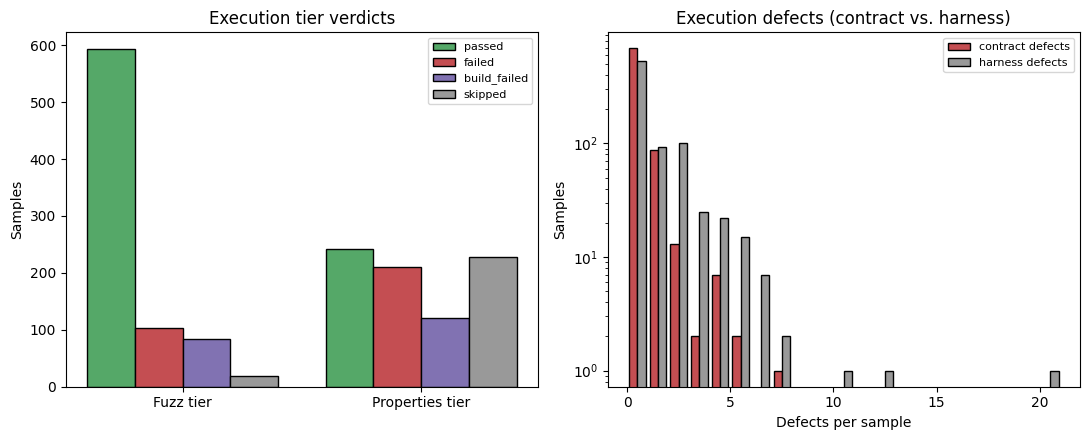

Fuzz pass rate:        74.1%
Execution-clean rate:  85.9% (zero contract defects)
Mean contract defects: 0.21
Samples with LLM-authored property tests: 515/800


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

tier_order = ["passed", "failed", "build_failed", "skipped"]
tier_colors = {"passed": "#55a868", "failed": COLOR_BAD, "build_failed": "#8172b2", "skipped": "#999999"}

fuzz_counts = Counter(r.fuzz_status for r in records)
prop_counts = Counter(r.properties_status for r in records)

x = np.arange(2)
width = 0.2
for i, status in enumerate(tier_order):
    vals = [fuzz_counts.get(status, 0), prop_counts.get(status, 0)]
    axes[0].bar(x + (i - 1.5) * width, vals, width, label=status, color=tier_colors[status], edgecolor="black")
axes[0].set_xticks(x, ["Fuzz tier", "Properties tier"])
axes[0].set_ylabel("Samples")
axes[0].set_title("Execution tier verdicts")
axes[0].legend(fontsize=8)

defects = [r.contract_defects for r in records]
harness_defects = [r.harness_defects for r in records]
max_d = max(max(defects, default=0), max(harness_defects, default=0), 1)
axes[1].hist([defects, harness_defects], bins=range(0, max_d + 2),
             label=["contract defects", "harness defects"],
             color=[COLOR_BAD, "#999999"], edgecolor="black")
axes[1].set_xlabel("Defects per sample")
axes[1].set_ylabel("Samples")
axes[1].set_title("Execution defects (contract vs. harness)")
axes[1].set_yscale("log")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Fuzz pass rate:        {ov['fuzz_pass_rate']:.1f}%")
print(f"Execution-clean rate:  {ov['execution_clean_rate']:.1f}% (zero contract defects)")
print(f"Mean contract defects: {ov['mean_contract_defects']:.2f}")
print(f"Samples with LLM-authored property tests: {sum(1 for r in records if r.property_tests > 0)}/{n}")


---
## 4. Security Analysis (Slither)

Static-analysis findings by impact severity. "Actionable" = High/Medium
impact at non-low confidence \u2014 the bar the security gate holds samples to.


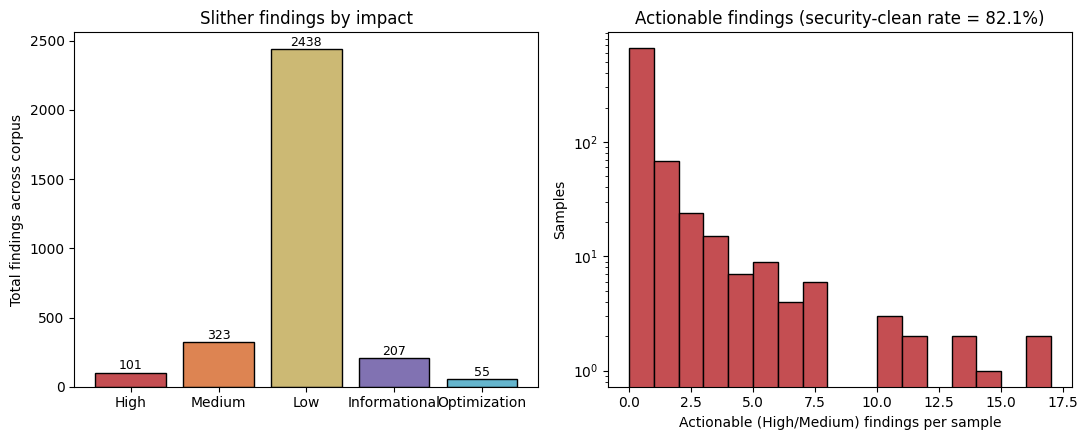

Mean findings/sample:   3.90
Mean actionable/sample: 0.53
Security-clean rate:    82.1%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

impact_order = ["High", "Medium", "Low", "Informational", "Optimization"]
impact_colors = {"High": "#c44e52", "Medium": "#dd8452", "Low": "#ccb974",
                  "Informational": "#8172b2", "Optimization": "#64b5cd"}
totals = Counter()
for r in records:
    totals.update(r.by_impact)
present = [i for i in impact_order if totals.get(i)]
axes[0].bar(present, [totals[i] for i in present],
            color=[impact_colors[i] for i in present], edgecolor="black")
axes[0].set_ylabel("Total findings across corpus")
axes[0].set_title("Slither findings by impact")
for i, lbl in enumerate(present):
    axes[0].text(i, totals[lbl] + max(totals.values()) * 0.01, str(totals[lbl]), ha="center", fontsize=9)

actionable = [r.n_actionable for r in records]
axes[1].hist(actionable, bins=range(0, max(actionable, default=0) + 2), color=COLOR_BAD, edgecolor="black")
axes[1].set_xlabel("Actionable (High/Medium) findings per sample")
axes[1].set_ylabel("Samples")
axes[1].set_title(f"Actionable findings (security-clean rate = {ov['security_clean_rate']:.1f}%)")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

print(f"Mean findings/sample:   {ov['mean_findings']:.2f}")
print(f"Mean actionable/sample: {ov['mean_actionable']:.2f}")
print(f"Security-clean rate:    {ov['security_clean_rate']:.1f}%")


---
## 5. Spec-Alignment (Semantic Similarity)

`compare_pair` similarity of each generated contract against its NL
requirement, scored during generation with the Solidity question bank.
`accepted` = similarity cleared the quality gate's threshold (0.8).


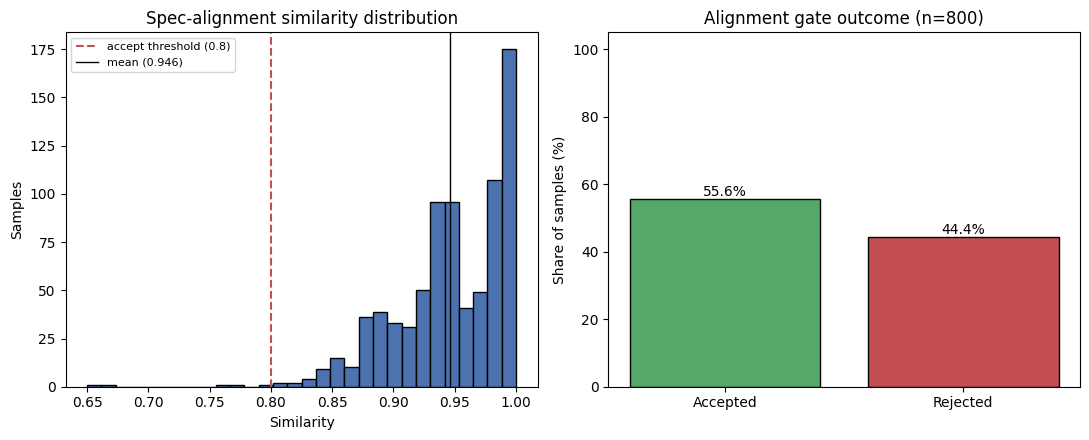

Repair attempts distribution: {0: 792, 1: 8}
Note: most samples are accepted on the FIRST attempt (repairs=0), so a low alignment-accept rate here reflects an initial-draft gap the repair loop did not close, not a lack of repair attempts.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].hist(sims, bins=30, color=COLOR, edgecolor="black")
axes[0].axvline(0.8, color=COLOR_BAD, linestyle="--", label="accept threshold (0.8)")
axes[0].axvline(ov["mean_similarity"], color="black", linestyle="-", linewidth=1, label=f"mean ({ov['mean_similarity']:.3f})")
axes[0].set_xlabel("Similarity")
axes[0].set_ylabel("Samples")
axes[0].set_title("Spec-alignment similarity distribution")
axes[0].legend(fontsize=8)

axes[1].bar(["Accepted", "Rejected"],
            [ov["alignment_accepted_rate"], 100 - ov["alignment_accepted_rate"]],
            color=["#55a868", COLOR_BAD], edgecolor="black")
for i, v in enumerate([ov["alignment_accepted_rate"], 100 - ov["alignment_accepted_rate"]]):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha="center")
axes[1].set_ylabel("Share of samples (%)")
axes[1].set_title(f"Alignment gate outcome (n={n})")
axes[1].set_ylim(0, 105)

plt.tight_layout()
plt.show()

repairs = Counter(r.repairs for r in records)
print(f"Repair attempts distribution: {dict(sorted(repairs.items()))}")
print("Note: most samples are accepted on the FIRST attempt (repairs=0), "
      "so a low alignment-accept rate here reflects an initial-draft gap the "
      "repair loop did not close, not a lack of repair attempts.")


---
## 6. Quality Tier & Domain (Category) Breakdown

How the four gates \u2014 and the resulting A/B grade \u2014 vary across the 20 DeFi
domains in the corpus.


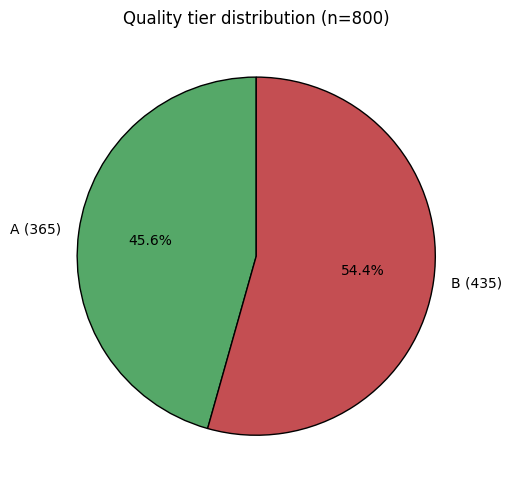

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
qc = ov["quality_counts"]
ax.pie([qc.get("A", 0), qc.get("B", 0)], labels=[f"A ({qc.get('A', 0)})", f"B ({qc.get('B', 0)})"],
       colors=["#55a868", COLOR_BAD], autopct="%1.1f%%", startangle=90, wedgeprops={"edgecolor": "black"})
ax.set_title(f"Quality tier distribution (n={n})")
plt.tight_layout()
plt.show()


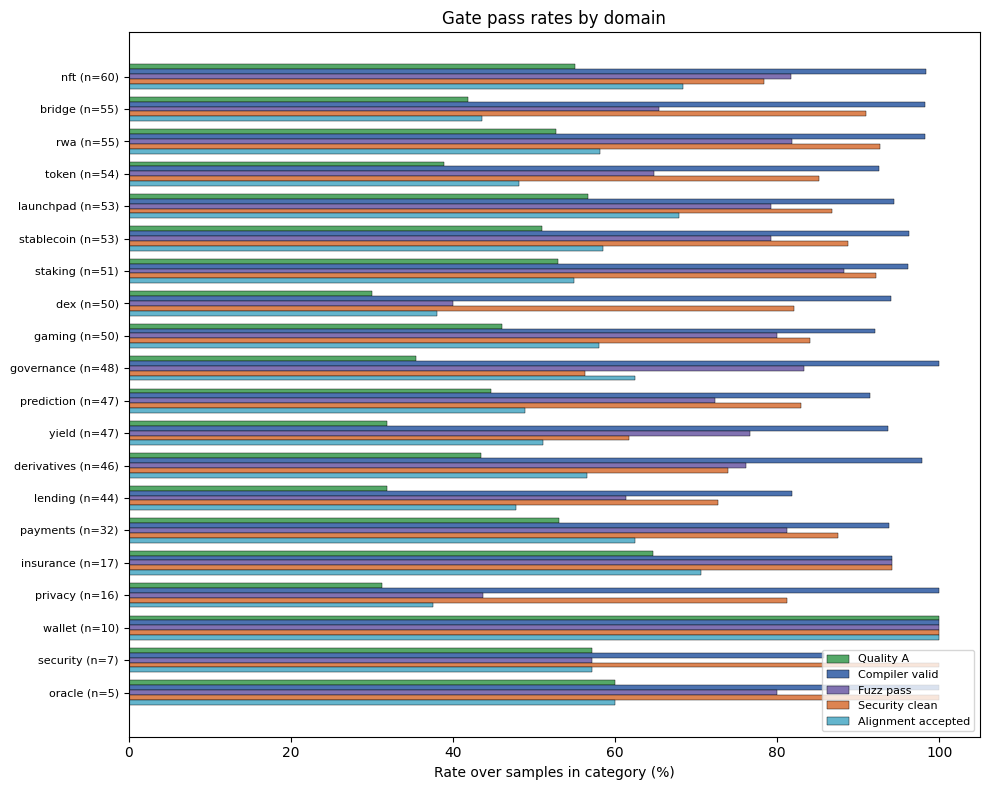

In [8]:
# Per-category gate pass rates, sorted by sample count
cat_names = list(cats.keys())
metrics = ["quality_A_rate", "valid_rate", "fuzz_pass_rate", "security_clean_rate", "alignment_accepted_rate"]
metric_labels = ["Quality A", "Compiler valid", "Fuzz pass", "Security clean", "Alignment accepted"]
metric_colors = ["#55a868", COLOR, "#8172b2", COLOR_MED, "#64b5cd"]

y = np.arange(len(cat_names))
h = 0.15
fig, ax = plt.subplots(figsize=(10, max(6, 0.4 * len(cat_names))))
for i, (m, lbl, c) in enumerate(zip(metrics, metric_labels, metric_colors)):
    vals = [cats[cat][m] for cat in cat_names]
    ax.barh(y + (i - 2) * h, vals, height=h, label=lbl, color=c, edgecolor="black", linewidth=0.3)
ax.set_yticks(y, [f"{cat} (n={cats[cat]['n']})" for cat in cat_names], fontsize=8)
ax.set_xlabel("Rate over samples in category (%)")
ax.set_xlim(0, 105)
ax.set_title("Gate pass rates by domain")
ax.legend(loc="lower right", fontsize=8)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


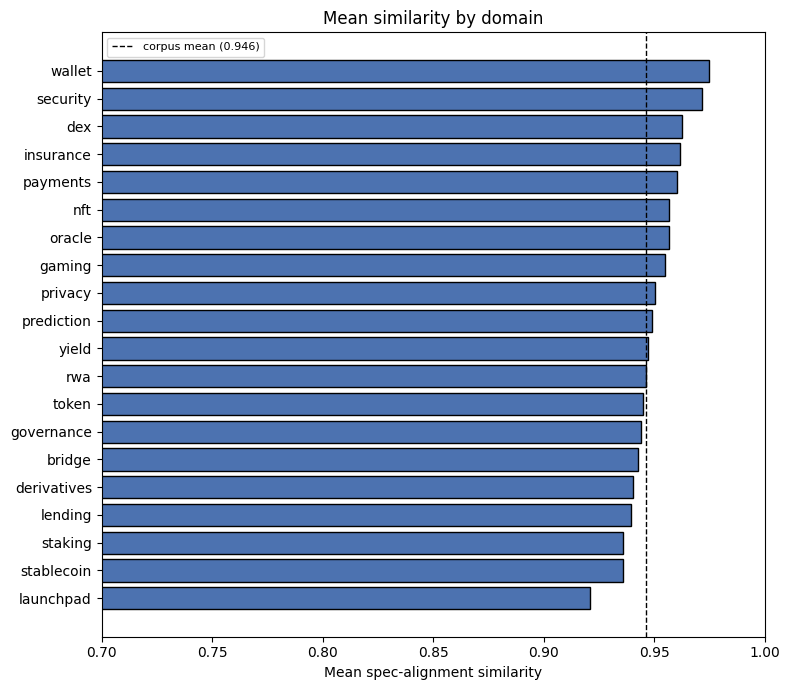

Category          n   A rate   Valid%   Fuzz%  Sec-clean%   Align%  MeanSim
----------------------------------------------------------------------------
nft              60    55.0%    98.3%   81.7%       78.3%    68.3%    0.957
bridge           55    41.8%    98.2%   65.5%       90.9%    43.6%    0.942
rwa              55    52.7%    98.2%   81.8%       92.7%    58.2%    0.946
token            54    38.9%    92.6%   64.8%       85.2%    48.1%    0.945
launchpad        53    56.6%    94.3%   79.2%       86.8%    67.9%    0.921
stablecoin       53    50.9%    96.2%   79.2%       88.7%    58.5%    0.936
staking          51    52.9%    96.1%   88.2%       92.2%    54.9%    0.936
dex              50    30.0%    94.0%   40.0%       82.0%    38.0%    0.963
gaming           50    46.0%    92.0%   80.0%       84.0%    58.0%    0.955
governance       48    35.4%   100.0%   83.3%       56.2%    62.5%    0.944
prediction       47    44.7%    91.5%   72.3%       83.0%    48.9%    0.949
yield      

In [9]:
# Mean spec-alignment similarity by category
cat_sorted = sorted(cat_names, key=lambda c: cats[c]["mean_similarity"] or 0)
sim_vals = [cats[c]["mean_similarity"] or 0 for c in cat_sorted]

fig, ax = plt.subplots(figsize=(8, max(5, 0.35 * len(cat_sorted))))
bars = ax.barh(cat_sorted, sim_vals, color=COLOR, edgecolor="black")
ax.axvline(ov["mean_similarity"], color="black", linestyle="--", linewidth=1,
           label=f"corpus mean ({ov['mean_similarity']:.3f})")
ax.set_xlabel("Mean spec-alignment similarity")
ax.set_xlim(0.7, 1.0)
ax.set_title("Mean similarity by domain")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"{'Category':<14}{'n':>5}{'A rate':>9}{'Valid%':>9}{'Fuzz%':>8}{'Sec-clean%':>12}{'Align%':>9}{'MeanSim':>9}")
print("-" * 76)
for cat, s in cats.items():
    ms = f"{s['mean_similarity']:.3f}" if s["mean_similarity"] is not None else "n/a"
    print(f"{cat:<14}{s['n']:>5}{s['quality_A_rate']:>8.1f}%{s['valid_rate']:>8.1f}%"
          f"{s['fuzz_pass_rate']:>7.1f}%{s['security_clean_rate']:>11.1f}%"
          f"{s['alignment_accepted_rate']:>8.1f}%{ms:>9}")


---
## 7. Which Gate Is the Bottleneck?

For samples that failed to reach quality A, which single gate (or
combination) was responsible? This decomposes the 435 "B" samples.


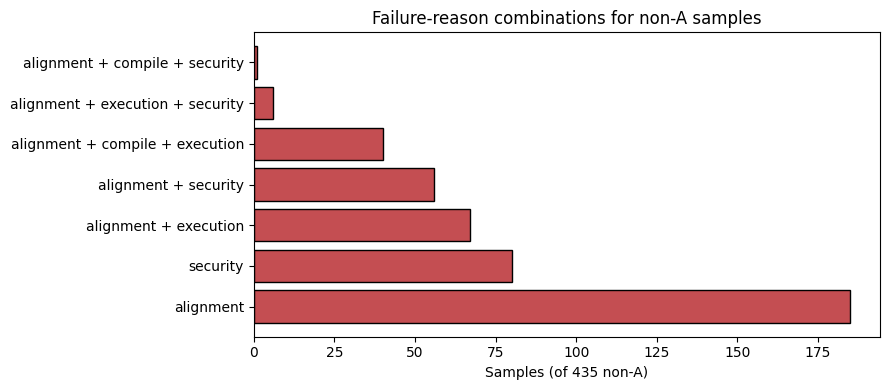

Of 435 non-A samples, each gate contributes to failure in:
  alignment   355 (81.6%)
  security    143 (32.9%)
  execution   113 (26.0%)
  compile      41 (9.4%)

Note: alignment is by far the most common single blocker — the accept threshold (0.8 similarity) is the tightest gate in this pipeline.


In [10]:
failed = [r for r in records if r.quality != "A"]
combo = Counter()
for r in failed:
    reasons = tuple(sorted(g for g, ok in [
        ("compile", not r.validation_ok),
        ("alignment", not r.alignment_ok),
        ("execution", not r.execution_ok),
        ("security", not r.security_ok),
    ] if ok))
    combo[reasons] += 1

labels = [" + ".join(k) if k else "(unknown)" for k in combo]
values = list(combo.values())
order = np.argsort(values)[::-1]

fig, ax = plt.subplots(figsize=(9, max(4, 0.4 * len(combo))))
ax.barh([labels[i] for i in order], [values[i] for i in order], color=COLOR_BAD, edgecolor="black")
ax.set_xlabel(f"Samples (of {len(failed)} non-A)")
ax.set_title("Failure-reason combinations for non-A samples")
plt.tight_layout()
plt.show()

# Single-gate attribution: how often each gate is *among* the failing gates
single = Counter()
for r in failed:
    for g, ok in [("compile", not r.validation_ok), ("alignment", not r.alignment_ok),
                  ("execution", not r.execution_ok), ("security", not r.security_ok)]:
        if ok:
            single[g] += 1
print(f"Of {len(failed)} non-A samples, each gate contributes to failure in:")
for g, c in single.most_common():
    print(f"  {g:<10} {c:>4} ({c/len(failed)*100:.1f}%)")
print("\nNote: alignment is by far the most common single blocker \u2014 the accept "
      "threshold (0.8 similarity) is the tightest gate in this pipeline.")


---
## 8. Cross-Gate Relationships

Does passing one gate predict passing another? Point-biserial correlations
and a compact contingency view across the four boolean gates plus the
continuous similarity score.


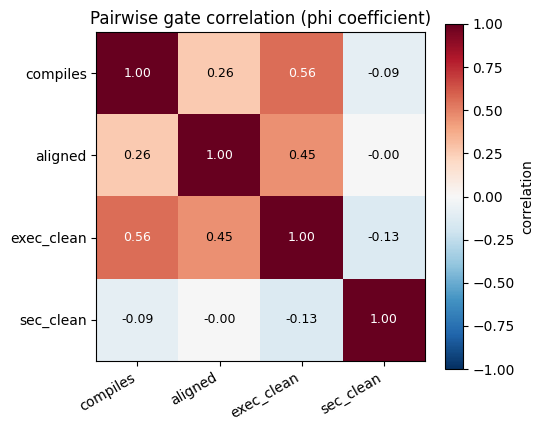

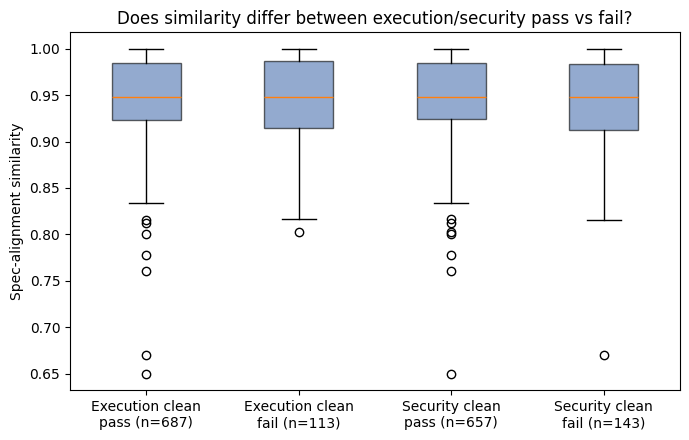

In [11]:
import itertools

gates = {
    "compiles": [r.validation_ok for r in records],
    "aligned": [r.alignment_ok for r in records],
    "exec_clean": [r.execution_ok for r in records],
    "sec_clean": [r.security_ok for r in records],
}
gate_names = list(gates)

corr = np.zeros((len(gate_names), len(gate_names)))
for i, a in enumerate(gate_names):
    for j, b in enumerate(gate_names):
        va, vb = np.array(gates[a], dtype=float), np.array(gates[b], dtype=float)
        if va.std() == 0 or vb.std() == 0:
            corr[i, j] = 1.0 if a == b else 0.0
        else:
            corr[i, j] = np.corrcoef(va, vb)[0, 1]

fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(gate_names)), gate_names, rotation=30, ha="right")
ax.set_yticks(range(len(gate_names)), gate_names)
for i, j in itertools.product(range(len(gate_names)), repeat=2):
    ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center",
             color="white" if abs(corr[i, j]) > 0.5 else "black", fontsize=9)
ax.set_title("Pairwise gate correlation (phi coefficient)")
fig.colorbar(im, shrink=0.8, label="correlation")
plt.tight_layout()
plt.show()

# Similarity by pass/fail on the other three gates
fig, ax = plt.subplots(figsize=(7, 4.5))
groups, glabels = [], []
for gate, name in [("execution_ok", "Execution clean"), ("security_ok", "Security clean")]:
    for val, tag in [(True, "pass"), (False, "fail")]:
        vals = [r.similarity for r in records if getattr(r, gate) == val and r.similarity is not None]
        if vals:
            groups.append(vals)
            glabels.append(f"{name}\n{tag} (n={len(vals)})")
bp = ax.boxplot(groups, tick_labels=glabels, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor(COLOR)
    patch.set_alpha(0.6)
ax.set_ylabel("Spec-alignment similarity")
ax.set_title("Does similarity differ between execution/security pass vs fail?")
plt.tight_layout()
plt.show()


---
## 9. Summary

Headline fidelity numbers for the ~800-sample full-pipeline corpus (no
baseline to compare against yet \u2014 report these as absolute figures, to be
revisited once `naive_glm` and/or `dataset/naive_glm` comparisons exist).


In [12]:
print(f"{'Metric':<38}{'Value':>10}")
print("-" * 48)
print(f"{'Samples':<38}{n:>10}")
print(f"{'Quality A rate':<38}{ov['quality_A_rate']:>9.1f}%")
print(f"{'Compiler valid rate':<38}{ov['valid_rate']:>9.1f}%")
print(f"{'Mean compiler errors':<38}{ov['mean_errors']:>10.3f}")
print(f"{'Foundry fuzz pass rate':<38}{ov['fuzz_pass_rate']:>9.1f}%")
print(f"{'Execution-clean rate':<38}{ov['execution_clean_rate']:>9.1f}%")
print(f"{'Mean contract defects':<38}{ov['mean_contract_defects']:>10.3f}")
print(f"{'Security-clean rate':<38}{ov['security_clean_rate']:>9.1f}%")
print(f"{'Mean findings/sample':<38}{ov['mean_findings']:>10.3f}")
print(f"{'Mean actionable findings/sample':<38}{ov['mean_actionable']:>10.3f}")
print(f"{'Spec-alignment accepted rate':<38}{ov['alignment_accepted_rate']:>9.1f}%")
print(f"{'Mean spec-alignment similarity':<38}{ov['mean_similarity']:>10.4f}")
print(f"{'All-4-gates-clean (quality A) rate':<38}{ov['all_four_gates_clean_rate']:>9.1f}%")
print()
best_cat = max(cats, key=lambda c: cats[c]["quality_A_rate"])
worst_cat = min(cats, key=lambda c: cats[c]["quality_A_rate"])
print(f"Best domain by quality-A rate:  {best_cat} ({cats[best_cat]['quality_A_rate']:.1f}%, n={cats[best_cat]['n']})")
print(f"Worst domain by quality-A rate: {worst_cat} ({cats[worst_cat]['quality_A_rate']:.1f}%, n={cats[worst_cat]['n']})")


Metric                                     Value
------------------------------------------------
Samples                                      800
Quality A rate                             45.6%
Compiler valid rate                        94.9%
Mean compiler errors                       0.111
Foundry fuzz pass rate                     74.1%
Execution-clean rate                       85.9%
Mean contract defects                      0.206
Security-clean rate                        82.1%
Mean findings/sample                       3.905
Mean actionable findings/sample            0.530
Spec-alignment accepted rate               55.6%
Mean spec-alignment similarity            0.9462
All-4-gates-clean (quality A) rate         45.6%

Best domain by quality-A rate:  wallet (100.0%, n=10)
Worst domain by quality-A rate: dex (30.0%, n=50)
